In [67]:
import pandas as pd
import numpy as np

In [68]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')    
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [70]:
df.isnull().sum().sort_values(ascending=False)

customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
PaperlessBilling    0
Contract            0
StreamingMovies     0
StreamingTV         0
TechSupport         0
OnlineBackup        0
gender              0
OnlineSecurity      0
InternetService     0
MultipleLines       0
PhoneService        0
tenure              0
Dependents          0
Partner             0
SeniorCitizen       0
Churn               0
dtype: int64

In [71]:
df["TotalCharges"].value_counts()

          11
20.2      11
19.75      9
20.05      8
19.9       8
          ..
6849.4     1
692.35     1
130.15     1
3211.9     1
6844.5     1
Name: TotalCharges, Length: 6531, dtype: int64

In [72]:
df["TotalCharges"] = df["TotalCharges"].replace(" ",np.nan)

In [73]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [74]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [75]:
print((df["TotalCharges"]==0).sum())

11


In [76]:
df["SeniorCitizen"].value_counts()

0    5901
1    1142
Name: SeniorCitizen, dtype: int64

In [77]:
for col in df.columns:
    print(df[col].value_counts())

7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: customerID, Length: 7043, dtype: int64
Male      3555
Female    3488
Name: gender, dtype: int64
0    5901
1    1142
Name: SeniorCitizen, dtype: int64
No     3641
Yes    3402
Name: Partner, dtype: int64
No     4933
Yes    2110
Name: Dependents, dtype: int64
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: tenure, Length: 73, dtype: int64
Yes    6361
No      682
Name: PhoneService, dtype: int64
No                  3390
Yes                 2971
No phone service     682
Name: MultipleLines, dtype: int64
Fiber optic    3096
DSL            2421
No             1526
Name: InternetService, dtype: int64
No                     3498
Yes                    2019
No internet service    1526
Name: OnlineSecurity, dtype: int64
No                     3088
Yes

In [78]:
col_to_simplify = ["OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]

In [79]:
for col in col_to_simplify:
    df[col] = df[col].replace("No internet service","No")

In [80]:
df["MultipleLines"] = df["MultipleLines"].replace("No phone service","No")

In [81]:
for col in df.columns:
    print(df[col].value_counts())

7590-VHVEG    1
3791-LGQCY    1
6008-NAIXK    1
5956-YHHRX    1
5365-LLFYV    1
             ..
9796-MVYXX    1
2637-FKFSY    1
1552-AAGRX    1
4304-TSPVK    1
3186-AJIEK    1
Name: customerID, Length: 7043, dtype: int64
Male      3555
Female    3488
Name: gender, dtype: int64
0    5901
1    1142
Name: SeniorCitizen, dtype: int64
No     3641
Yes    3402
Name: Partner, dtype: int64
No     4933
Yes    2110
Name: Dependents, dtype: int64
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: tenure, Length: 73, dtype: int64
Yes    6361
No      682
Name: PhoneService, dtype: int64
No     4072
Yes    2971
Name: MultipleLines, dtype: int64
Fiber optic    3096
DSL            2421
No             1526
Name: InternetService, dtype: int64
No     5024
Yes    2019
Name: OnlineSecurity, dtype: int64
No     4614
Yes    2429
Name: OnlineBackup, dtype: int64
No     4621
Yes    2422
Name: DeviceProtection, dtype: int64
No     4999
Yes    2044


In [82]:
df["customerID"].duplicated().sum()

0

In [83]:
df = df.drop("customerID",axis=1)

In [84]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


visulizations

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

In [86]:
df["Churn"].value_counts(normalize=True)
#imbalanced data

No     0.73463
Yes    0.26537
Name: Churn, dtype: float64

<Axes: xlabel='Contract', ylabel='count'>

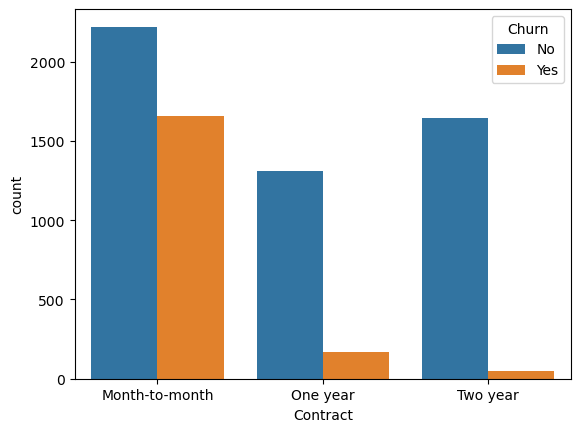

In [87]:
sns.countplot(hue="Churn",x="Contract",data=df)

<Axes: xlabel='tenure', ylabel='Count'>

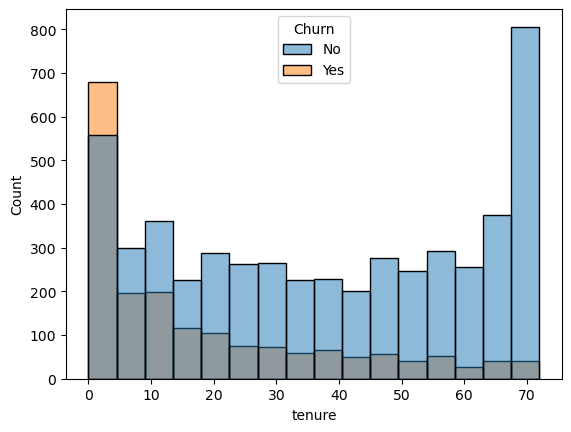

In [88]:
sns.histplot(hue="Churn",x="tenure",data=df)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

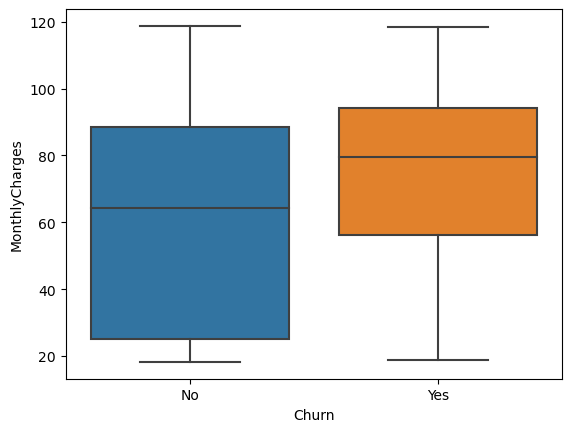

In [89]:
sns.boxplot(data=df,x="Churn",y="MonthlyCharges")

<Axes: >

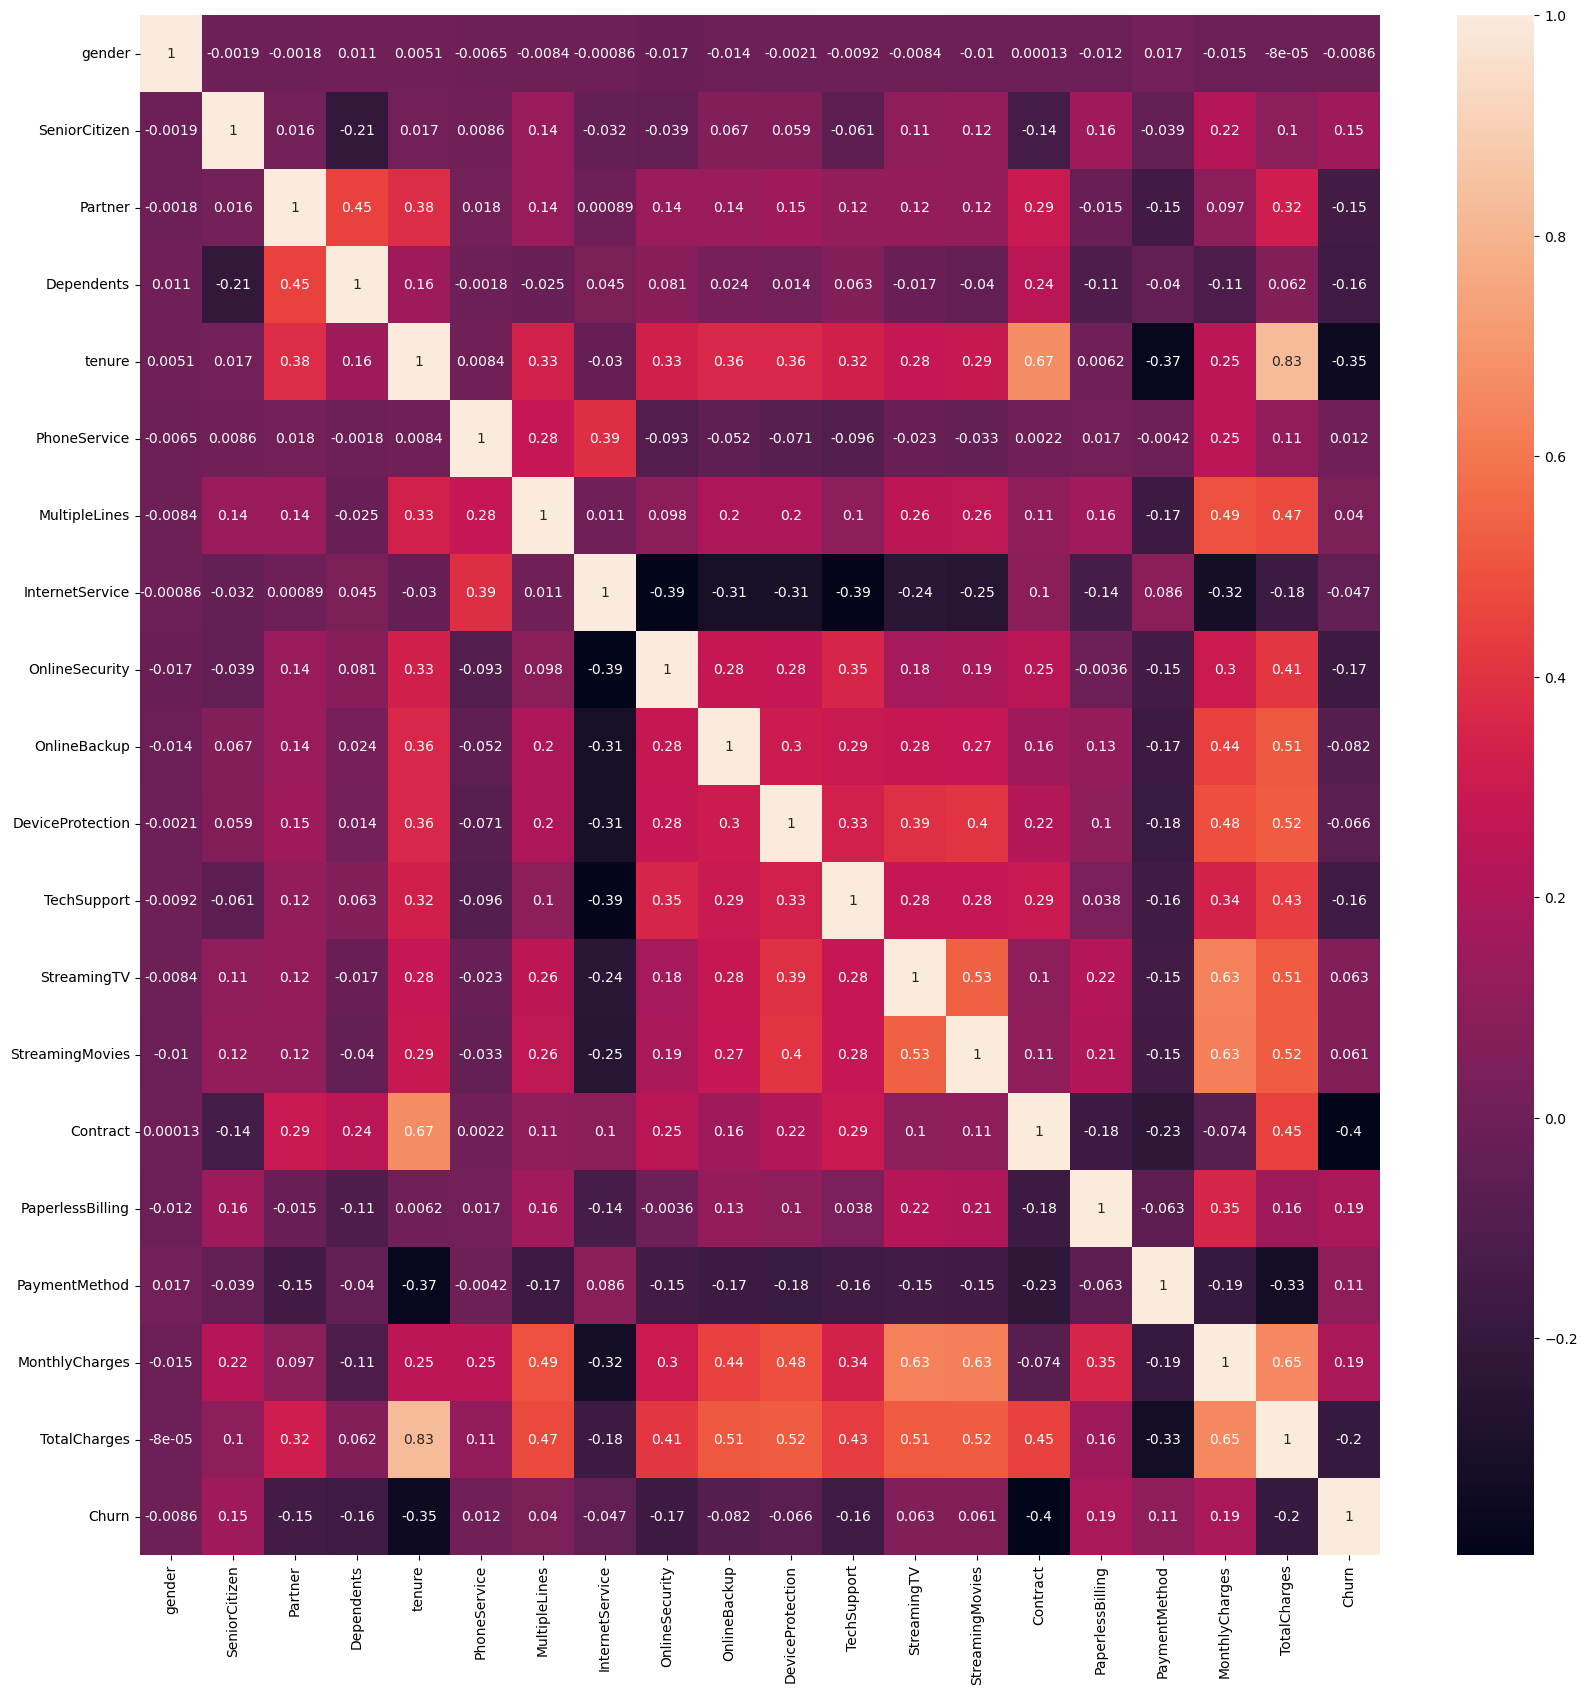

In [90]:
df_encoded = df.copy()

for col in df_encoded.select_dtypes(include=["object"]).columns:
    df_encoded[col] = df_encoded[col].astype("category").cat.codes

plt.figure(figsize=(20,20))
sns.heatmap(df_encoded.corr(),annot=True)

In [91]:
def tenure_bucket(t):
    if t<12:
        return "0-1 year"
    elif t<=24:
        return "1-2 years"
    elif t<=36:
        return "2-3 years"
    elif t<=48:
        return "3-4 years"
    else:
        return "4+ years"
df["tenure_bucket"] = df["tenure"].apply(tenure_bucket)

In [92]:
service_cols = ["PhoneService","MultipleLines","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]

In [93]:
df["numService"] = (df[service_cols]=="Yes").sum(axis=1)

In [94]:
df["numService"].value_counts()

1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
0      80
Name: numService, dtype: int64

In [95]:
df["Churn"] = df["Churn"].map({"Yes":1,"No":0})

catgorical_cols = df.select_dtypes(include=["object"]).columns.to_list()

df_model = pd.get_dummies(df,columns=catgorical_cols,drop_first=True)


In [96]:
X = df_model.drop("Churn",axis=1)
y = df_model["Churn"]

In [117]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state=42)

In [120]:
from imblearn.over_sampling import SMOTE 
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [121]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

lr = LogisticRegression()
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()

lr.fit(X_resampled, y_resampled)
rf.fit(X_resampled, y_resampled)
gb.fit(X_resampled, y_resampled)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


GradientBoostingClassifier()

In [122]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

for name, model, X_te in [('LogReg', lr, X_test),
                           ('RandomForest', rf, X_test),
                           ('GradientBoosting', gb, X_test)]:
    preds = model.predict(X_te)
    probs = model.predict_proba(X_te)[:, 1]
    print(f"\n--- {name} ---")
    print(classification_report(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test, probs))


--- LogReg ---
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      1036
           1       0.57      0.69      0.62       373

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.78      0.79      1409

ROC-AUC: 0.8418347014191518

--- RandomForest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1036
           1       0.99      0.99      0.99       373

    accuracy                           1.00      1409
   macro avg       0.99      0.99      0.99      1409
weighted avg       1.00      1.00      1.00      1409

ROC-AUC: 0.9999365987971887

--- GradientBoosting ---
              precision    recall  f1-score   support

           0       0.90      0.81      0.85      1036
           1       0.59      0.75      0.66       373

    accuracy                           0.80      1409
   macro